In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# plt.rcParams.update({
#     "text.usetex": True,    # 使用LaTeX渲染所有文字
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],    # LaTeX默认字体
#     "font.size": 12,        # 默认字体大小
#     "axes.labelsize": 12,   # 轴标签字体大小
#     "legend.fontsize": 12   # 图例字体大小
# })

In [3]:
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,        # 默认字体大小
    "axes.labelsize": 10,   # 轴标签字体大小
    "legend.fontsize": 10,  # 图例字体大小
    "mathtext.fontset": "stix",  # 数学字体设置为 STIX，这个与 Times New Roman 很接近
})

In [4]:
def parse_history_file(filename):
    headers = []
    data = []
    
    with open(filename, 'r') as f:
        for line in f:
            if not line.strip():
                continue
                
            # 处理注释行中的列名
            if line.startswith('# ['):
                # 先用']'分割行,这样可以分开每个列定义
                parts = line.strip('# \n').split(']')
                for part in parts:
                    if '=' in part:
                        # 提取等号后面的名称
                        header = part.split('=')[1].strip()
                        # 移除开头的'['(如果存在)
                        if header.startswith('['):
                            header = header[1:]
                        # 移除方括号及其中的数字
                        header = header.split('[')[0].strip()
                        if header:  # 确保不是空字符串
                            headers.append(header)
            
            # 处理数据行
            elif not line.startswith('#'):
                row_data = [float(x) for x in line.split()]
                data.append(row_data)
    
    # 将数据转换为字典格式
    result = {}
    for i, header in enumerate(headers):
        result[header] = [row[i] for row in data]
    
    return result

In [5]:
a05e00_3d = "/home/zhangzelin/projects/kharma-data-sync/20241104_cuda_kz_sane_a05000_eta+00_128-96-96_10-20/kz_torus.hst"
a05ez5_3d = "/home/zhangzelin/projects/kharma-data-sync/20241104_cuda_kz_sane_a05000_eta+05_128-96-96_10-20/kz_torus.hst"
a09e00_3d = "/home/zhangzelin/projects/kharma-data-sync/20241104_cuda_kz_sane_a09375_eta+00_128-96-96_10-20/kz_torus.hst"
a09ez5_3d = "/home/zhangzelin/projects/kharma-data-sync/20241104_cuda_kz_sane_a09375_eta+05_128-96-96_10-20/kz_torus.hst"

a05e00_3d_history_data = parse_history_file(a05e00_3d)
a09e00_3d_history_data = parse_history_file(a09e00_3d)
a05ez5_3d_history_data = parse_history_file(a05ez5_3d)
a09ez5_3d_history_data = parse_history_file(a09ez5_3d)



In [7]:
a05e00_3d_t = a05e00_3d_history_data['time']
a05e00_3d_Phi_EH = a05e00_3d_history_data['Phi_EH']
a05e00_3d_Phi_5M = a05e00_3d_history_data['Phi_5M']
a05e00_3d_Mdot_EH = a05e00_3d_history_data['Mdot_EH']
a05e00_3d_Mdot_5M = a05e00_3d_history_data['Mdot_5M']

a09e00_3d_t = a09e00_3d_history_data['time']
a09e00_3d_Phi_EH = a09e00_3d_history_data['Phi_EH']
a09e00_3d_Phi_5M = a09e00_3d_history_data['Phi_5M']
a09e00_3d_Mdot_EH = a09e00_3d_history_data['Mdot_EH']
a09e00_3d_Mdot_5M = a09e00_3d_history_data['Mdot_5M']


a05ez5_3d_t = a05ez5_3d_history_data['time']
a05ez5_3d_Phi_EH = a05ez5_3d_history_data['Phi_EH']
a05ez5_3d_Phi_5M = a05ez5_3d_history_data['Phi_5M']
a05ez5_3d_Mdot_EH = a05ez5_3d_history_data['Mdot_EH']
a05ez5_3d_Mdot_5M = a05ez5_3d_history_data['Mdot_5M']

a09ez5_3d_t = a09ez5_3d_history_data['time']
a09ez5_3d_Phi_EH = a09ez5_3d_history_data['Phi_EH']
a09ez5_3d_Phi_5M = a09ez5_3d_history_data['Phi_5M']
a09ez5_3d_Mdot_EH = a09ez5_3d_history_data['Mdot_EH']
a09ez5_3d_Mdot_5M = a09ez5_3d_history_data['Mdot_5M']



KeyError: 'Mdot_EH'

In [8]:
print(np.array(a05e00_3d_t).shape)

(10001,)
(10521,)


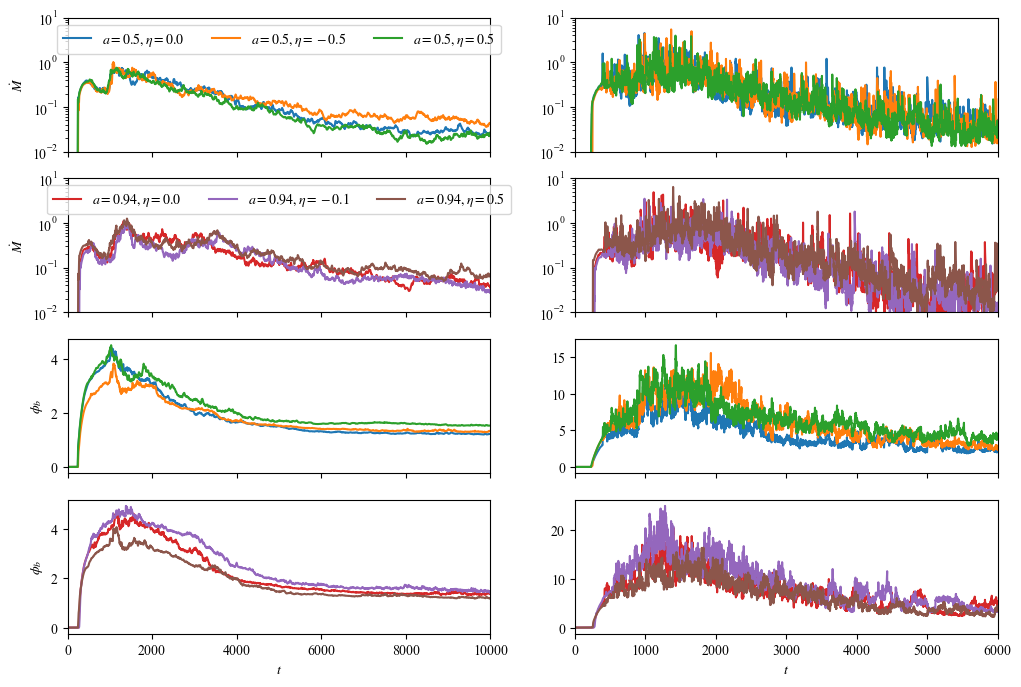

In [9]:
avt = 5000

# phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot0)]
# phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot2)]
# phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot3)]
# phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot1)]
# phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot4)]
# phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot5)]

phi_b_a05e00_3d = [a05e00_3d_t, a05e00_3d_Phi_EH/np.sqrt(np.average(a05e00_3d_Mdot_EH[avt:]))]
phi_b_a05ez5_3d = [a05ez5_3d_t, a05ez5_3d_Phi_EH/np.sqrt(np.average(a05ez5_3d_Mdot_EH[avt:]))]
phi_b_a09e00_3d = [a09e00_3d_t, a09e00_3d_Phi_EH/np.sqrt(np.average(a09e00_3d_Mdot_EH[avt:]))]
phi_b_a09ez5_3d = [a09ez5_3d_t, a09ez5_3d_Phi_EH/np.sqrt(np.average(a09ez5_3d_Mdot_EH[avt:]))]


figs0, axs0 = plt.subplots(4, 1, figsize=(12, 8))
axs0[0,0].plot(a05e00_3d_t[::], a05e00_3d_Mdot_EH[::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
axs0[0,0].plot(a05ez5_3d_t[::], a05ez5_3d_Mdot_EH[::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
axs0[1,0].plot(a09e00_3d_t[::], a09e00_3d_Mdot_EH[::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
axs0[1,0].plot(a09ez5_3d_t[::], a09ez5_3d_Mdot_EH[::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')


y_ticks_mdot_3d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_mdot_2d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_phi_b_3d = [1e0, 1e1]
y_ticks_phi_b_2d = [1e0, 1e1, 1e2]
axs0[0].set_ylabel(r'$\dot{M}$')
axs0[0].set_yscale('log')
axs0[0].set_ylim(1e-2, 1e1)
axs0[0].set_yticks(y_ticks_mdot_3d)
axs0[0].set_xlim(0, 10000)
axs0[0].set_xticklabels([])
axs0[0].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='upper center', ncol=3)


axs0[1].set_ylabel(r'$\dot{M}$')
axs0[1].set_yscale('log')
axs0[1].set_ylim(1e-2, 1e1)
axs0[1].set_yticks(y_ticks_mdot_3d)
axs0[1].set_xlim(0, 10000)
axs0[1].set_xticklabels([])
axs0[1].legend([r'$a=0.94, \eta=0.0$', r'$a=0.94, \eta=-0.1$', r'$a=0.94, \eta=0.5$'], loc='upper center', ncol=3)



axs0[2].plot(phi_b_a05e00_3d[0][::], phi_b_a05e00_3d[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
axs0[2].plot(phi_b_a05ez5_3d[0][::], phi_b_a05ez5_3d[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
axs0[3].plot(phi_b_a09e00_3d[0][::], phi_b_a09e00_3d[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
axs0[3].plot(phi_b_a09ez5_3d[0][::], phi_b_a09ez5_3d[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')


axs0[2].set_ylabel(r'$\phi_b$')
# axs0[2,0].set_yscale('log')
# axs0[2,0].set_ylim(1e-0, 1e1)
# axs0[2,0].set_yticks(y_ticks_phi_b_3d)
axs0[2].set_xlim(0, 10000)
axs0[2].set_xticklabels([])
# axs0[2,0].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='lower right')

axs0[3].set_ylabel(r'$\phi_b$')
# axs0[3,0].set_yscale('log')
# axs0[3,0].set_ylim(1e-0, 1e1)
# axs0[3,0].set_yticks(y_ticks_phi_b_3d)
axs0[3].set_xlabel(r'$t$')
axs0[3].set_xlim(0, 10000)
# axs0[3].legend([r'$a=0.9375, \eta=0.0$', r'$a=0.9375, \eta=-0.1$', r'$a=0.9375, \eta=0.5$'], loc='lower right')


# plt.savefig('kz_analysis_result_t-mdot_phi_b.png', dpi=300)
plt.show()

In [10]:
# def moving_average(data, window_size):
#     return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# # 对数据进行平滑处理
# window = 50  # 可以调整窗口大小
# a05ef5_2d_Mdot_EH_smoothed_t = a05ef5_2d_Mdot_EH[0][window-1:]  # 需要调整时间数组以匹配平滑后的数据长度
# a05ef5_2d_Mdot_EH_smoothed_data = moving_average(a05ef5_2d_Mdot_EH[1], window)


/tmp/ipykernel_2458569/1337655661.py:144: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


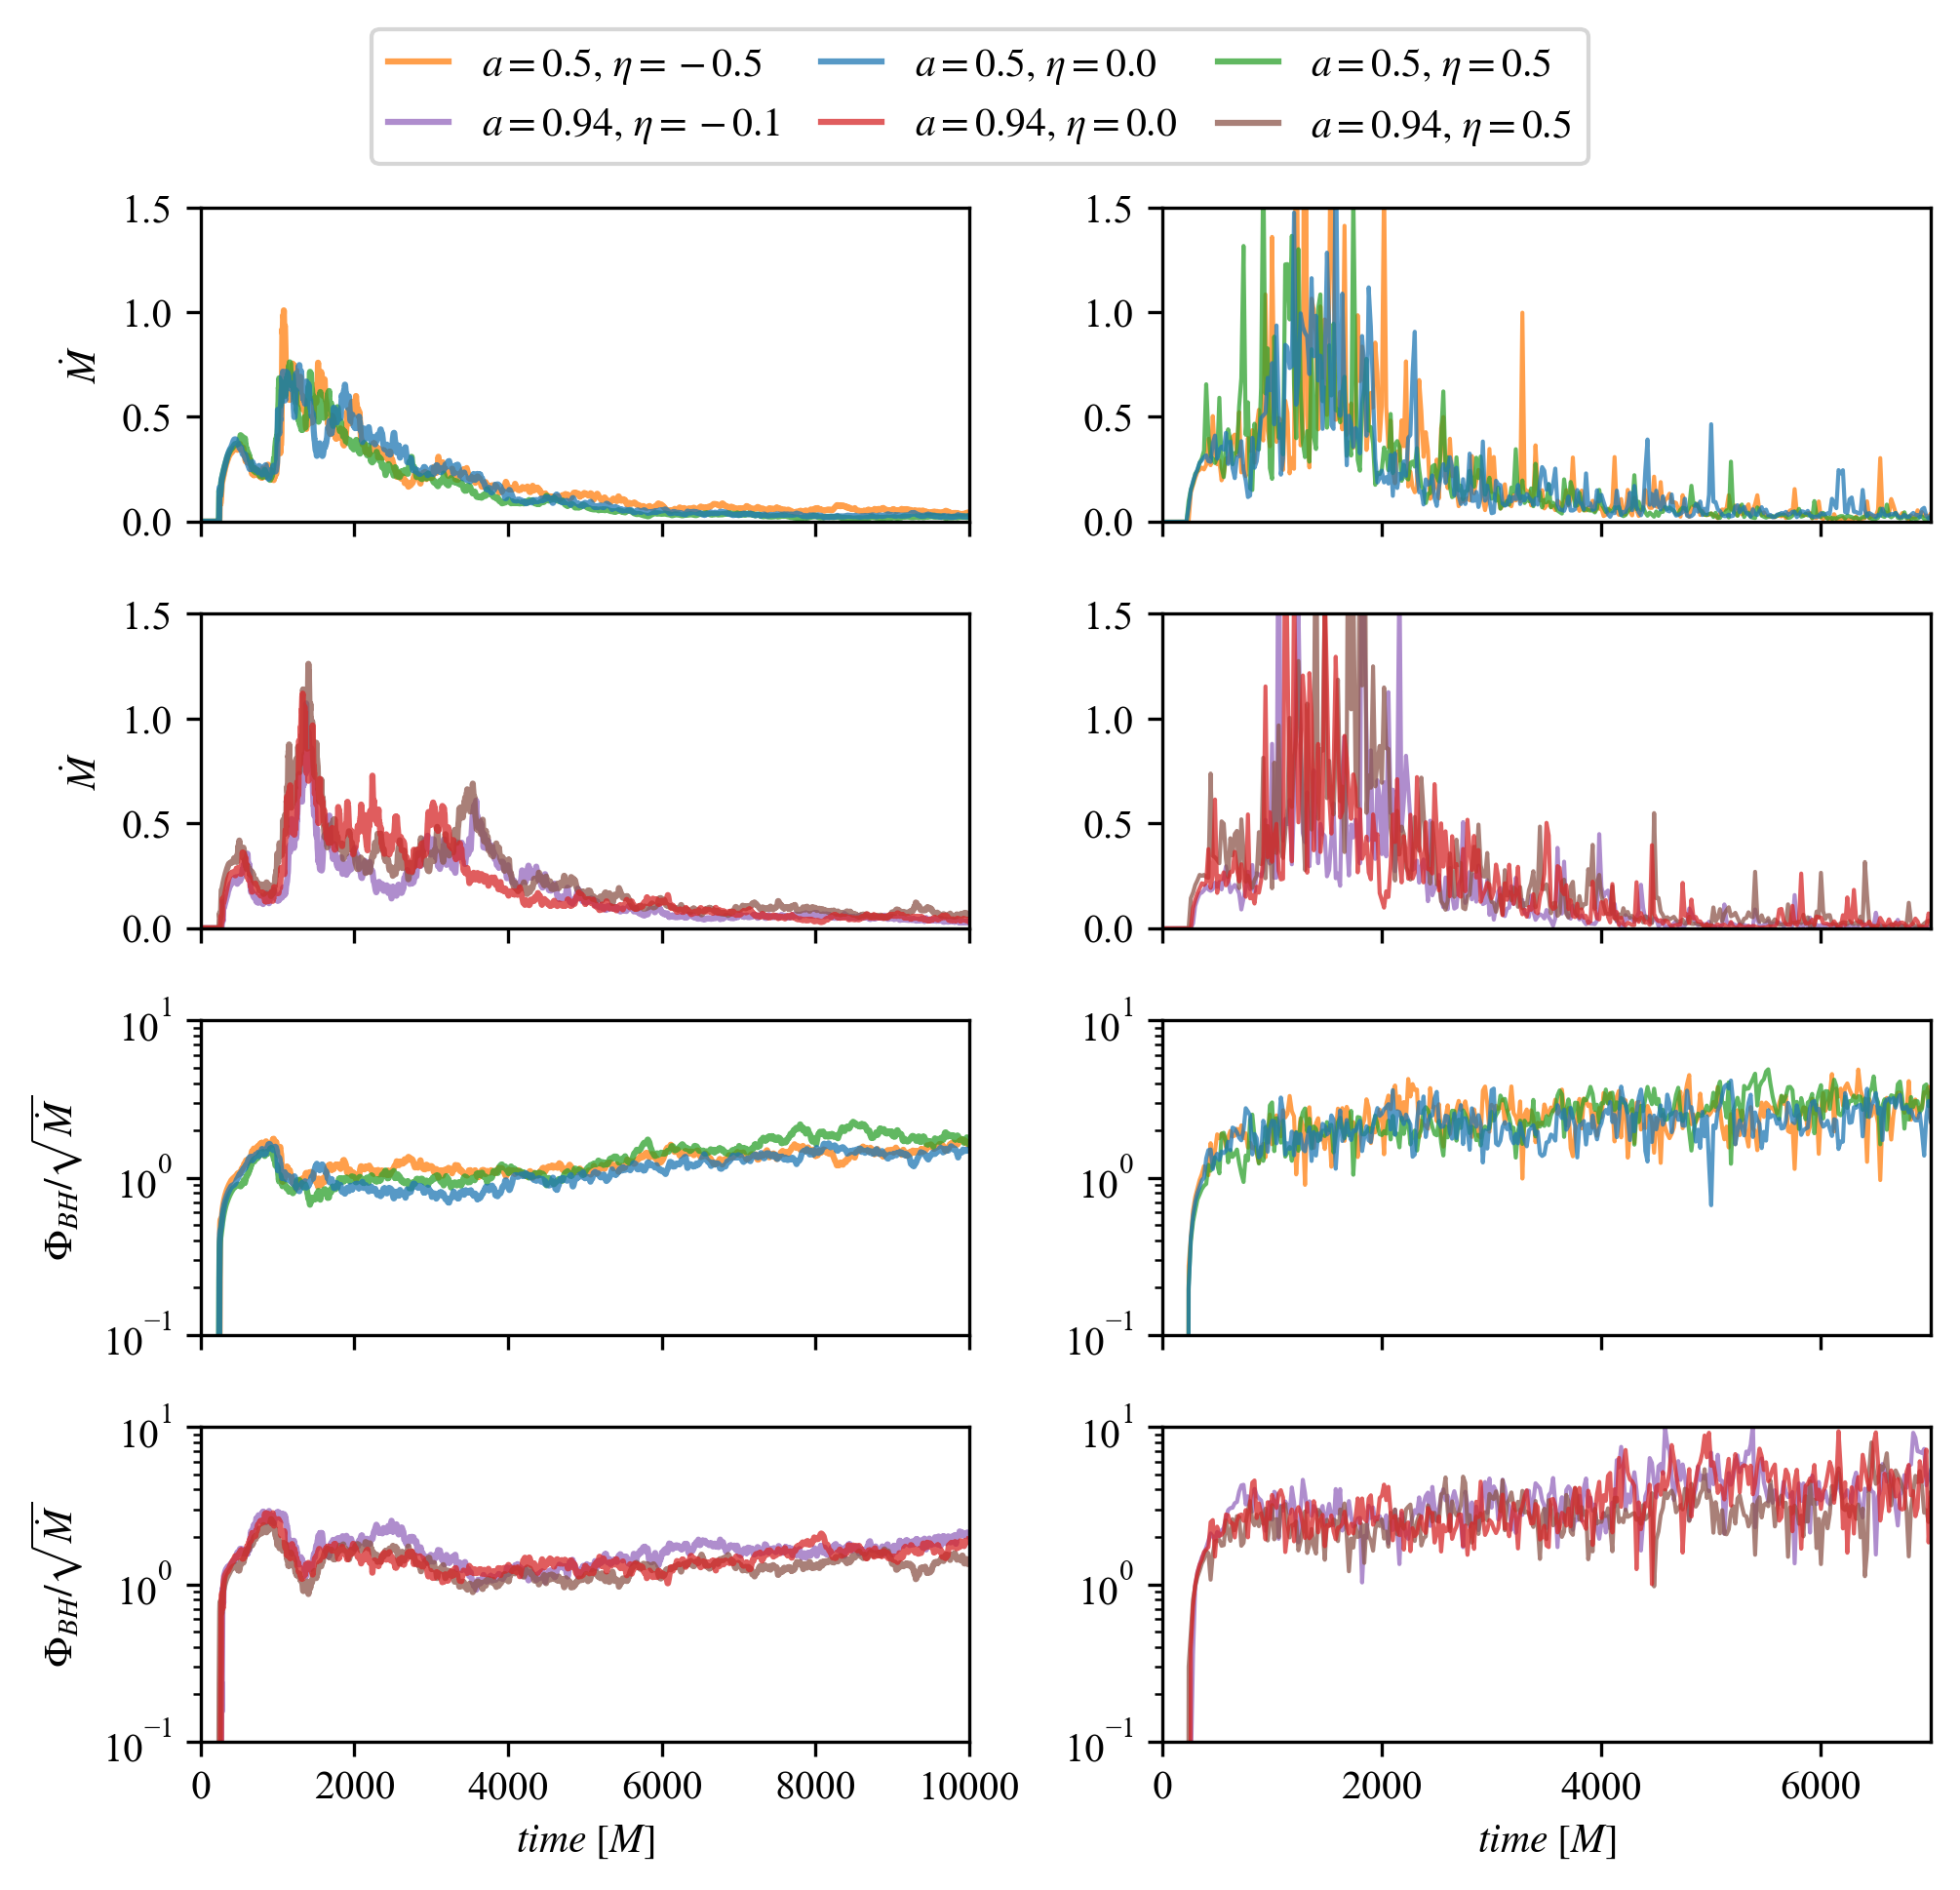

In [14]:
# avt = 5000
tstart = 0
tend = 7000
dt = 20

# phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot0)]
# phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot2)]
# phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot3)]
# phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot1)]
# phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot4)]
# phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot5)]

phi_b_a05e00_3d = [a05e00_3d_t, a05e00_3d_Phi_EH/np.sqrt((a05e00_3d_Mdot_EH[:]))]
phi_b_a05ef5_3d = [a05ef5_3d_t, a05ef5_3d_Phi_EH/np.sqrt((a05ef5_3d_Mdot_EH[:]))]
phi_b_a05ez5_3d = [a05ez5_3d_t, a05ez5_3d_Phi_EH/np.sqrt((a05ez5_3d_Mdot_EH[:]))]
phi_b_a09e00_3d = [a09e00_3d_t, a09e00_3d_Phi_EH/np.sqrt((a09e00_3d_Mdot_EH[:]))]
phi_b_a09ef1_3d = [a09ef1_3d_t, a09ef1_3d_Phi_EH/np.sqrt((a09ef1_3d_Mdot_EH[:]))]
phi_b_a09ez5_3d = [a09ez5_3d_t, a09ez5_3d_Phi_EH/np.sqrt((a09ez5_3d_Mdot_EH[:]))]

phi_b_a05e00_2d = [a05e00_2d_t, a05e00_2d_Phi_EH/np.sqrt((a05e00_2d_Mdot_EH[:]))]
phi_b_a05ef5_2d = [a05ef5_2d_t, a05ef5_2d_Phi_EH/np.sqrt((a05ef5_2d_Mdot_EH[:]))]
phi_b_a05ez5_2d = [a05ez5_2d_t, a05ez5_2d_Phi_EH/np.sqrt((a05ez5_2d_Mdot_EH[:]))]
phi_b_a09e00_2d = [a09e00_2d_t, a09e00_2d_Phi_EH/np.sqrt((a09e00_2d_Mdot_EH[:]))]
phi_b_a09ef1_2d = [a09ef1_2d_t, a09ef1_2d_Phi_EH/np.sqrt((a09ef1_2d_Mdot_EH[:]))]
phi_b_a09ez5_2d = [a09ez5_2d_t, a09ez5_2d_Phi_EH/np.sqrt((a09ez5_2d_Mdot_EH[:]))]


figs0, axs0 = plt.subplots(4, 2, figsize=(6.8, 6), dpi=300, layout='constrained')

axs0[0,0].plot(a05ef5_3d_t[::], a05ef5_3d_Mdot_EH[::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=1.5, alpha=0.75)
axs0[0,0].plot(a05ez5_3d_t[::], a05ez5_3d_Mdot_EH[::], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=1.5, alpha=0.75)
axs0[0,0].plot(a05e00_3d_t[::], a05e00_3d_Mdot_EH[::], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=1.5, alpha=0.75)

axs0[1,0].plot(a09ef1_3d_t[::], a09ef1_3d_Mdot_EH[::], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=1.5, alpha=0.75)
axs0[1,0].plot(a09ez5_3d_t[::], a09ez5_3d_Mdot_EH[::], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=1.5, alpha=0.75)
axs0[1,0].plot(a09e00_3d_t[::], a09e00_3d_Mdot_EH[::], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=1.5, alpha=0.75)


axs0[0,1].plot(a05ef5_2d_t[::dt], a05ef5_2d_Mdot_EH[::dt], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=1.0, alpha=0.75)
axs0[0,1].plot(a05ez5_2d_t[::dt], a05ez5_2d_Mdot_EH[::dt], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=1.0, alpha=0.75)
axs0[0,1].plot(a05e00_2d_t[::dt], a05e00_2d_Mdot_EH[::dt], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=1.0, alpha=0.75)

axs0[1,1].plot(a09ef1_2d_t[::dt], a09ef1_2d_Mdot_EH[::dt], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=1.0, alpha=0.75)
axs0[1,1].plot(a09ez5_2d_t[::dt], a09ez5_2d_Mdot_EH[::dt], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=1.0, alpha=0.75)
axs0[1,1].plot(a09e00_2d_t[::dt], a09e00_2d_Mdot_EH[::dt], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=1.0, alpha=0.75)

y_ticks_mdot_3d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_mdot_2d = [1e-2, 1e-1, 1e0, 1e1]
y_ticks_phi_b_3d = [1e-1, 1e0, 1e1]
y_ticks_phi_b_2d = [1e-1, 1e0, 1e1]
axs0[0,0].set_ylabel(r'$\dot{M}$')
# axs0[0,0].set_yscale('log')
# axs0[0,0].set_ylim(1e-2, 1e1)
# axs0[0,0].set_yticks(y_ticks_mdot_3d)
axs0[0,0].set_ylim(0, 1.5)
axs0[0,0].set_xlim(0, 10000)
axs0[0,0].set_xticklabels([])
# axs0[0,0].legend(loc='upper right', ncol=1)

# axs0[0,1].set_yscale('log')
# axs0[0,1].set_ylim(1e-2, 1e1)
# axs0[0,1].set_yticks(y_ticks_mdot_2d)
axs0[0,1].set_ylim(0, 1.5)
axs0[0,1].set_xlim(tstart, tend)
axs0[0,1].set_xticklabels([])

axs0[1,0].set_ylabel(r'$\dot{M}$')
# axs0[1,0].set_yscale('log')
# axs0[1,0].set_ylim(1e-2, 1e1)
# axs0[1,0].set_yticks(y_ticks_mdot_3d)
axs0[1,0].set_ylim(0, 1.5)
axs0[1,0].set_xlim(0, 10000)
axs0[1,0].set_xticklabels([])
# axs0[1,0].legend(loc='upper right', ncol=1)

# axs0[1,1].set_yscale('log')
# axs0[1,1].set_ylim(1e-3, 1e1)
# axs0[1,1].set_yticks([1e-3, 1e-2, 1e-1, 1e0, 1e1])
axs0[1,1].set_ylim(0, 1.5)
axs0[1,1].set_xlim(tstart, tend)
axs0[1,1].set_xticklabels([])


axs0[2,0].plot(phi_b_a05ef5_3d[0][::], phi_b_a05ef5_3d[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=1.5, alpha=0.75)
axs0[2,0].plot(phi_b_a05ez5_3d[0][::], phi_b_a05ez5_3d[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=1.5, alpha=0.75)
axs0[2,0].plot(phi_b_a05e00_3d[0][::], phi_b_a05e00_3d[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=1.5, alpha=0.75)

axs0[3,0].plot(phi_b_a09ef1_3d[0][::], phi_b_a09ef1_3d[1][::], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=1.5, alpha=0.75)   
axs0[3,0].plot(phi_b_a09ez5_3d[0][::], phi_b_a09ez5_3d[1][::], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=1.5, alpha=0.75)
axs0[3,0].plot(phi_b_a09e00_3d[0][::], phi_b_a09e00_3d[1][::], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=1.5, alpha=0.75)

axs0[2,1].plot(phi_b_a05ef5_2d[0][::dt], phi_b_a05ef5_2d[1][::dt], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$', linewidth=1.0, alpha=0.75)
axs0[2,1].plot(phi_b_a05ez5_2d[0][::dt], phi_b_a05ez5_2d[1][::dt], '#2ca02c', label=r'$a=0.5, \eta=0.5$', linewidth=1.0, alpha=0.75)
axs0[2,1].plot(phi_b_a05e00_2d[0][::dt], phi_b_a05e00_2d[1][::dt], '#1f77b4', label=r'$a=0.5, \eta=0.0$', linewidth=1.0, alpha=0.75)

axs0[3,1].plot(phi_b_a09ef1_2d[0][::dt], phi_b_a09ef1_2d[1][::dt], '#9467bd', label=r'$a=0.94, \eta=-0.1$', linewidth=1.0, alpha=0.75)
axs0[3,1].plot(phi_b_a09ez5_2d[0][::dt], phi_b_a09ez5_2d[1][::dt], '#8c564b', label=r'$a=0.94, \eta=0.5$', linewidth=1.0, alpha=0.75)
axs0[3,1].plot(phi_b_a09e00_2d[0][::dt], phi_b_a09e00_2d[1][::dt], '#d62728', label=r'$a=0.94, \eta=0.0$', linewidth=1.0, alpha=0.75)

axs0[2,0].set_ylabel(r'$\Phi_{BH}/\sqrt{\dot{M}}$')
axs0[2,0].set_yscale('log')
axs0[2,0].set_ylim(1e-1, 1e1)
axs0[2,0].set_yticks(y_ticks_phi_b_3d)
axs0[2,0].set_xlim(0, 10000)
axs0[2,0].set_xticklabels([])

axs0[3,0].set_ylabel(r'$\Phi_{BH}/\sqrt{\dot{M}}$')
axs0[3,0].set_yscale('log')
axs0[3,0].set_ylim(1e-1, 1e1)
axs0[3,0].set_yticks(y_ticks_phi_b_3d)
axs0[3,0].set_xlabel(r'$time ~[M]$')
axs0[3,0].set_xlim(0, 10000)

axs0[2,1].set_yscale('log')
axs0[2,1].set_ylim(1e-1, 1e1)
axs0[2,1].set_yticks(y_ticks_phi_b_2d)
axs0[2,1].set_xlim(tstart, tend)
axs0[2,1].set_xticklabels([])

axs0[3,1].set_yscale('log')
axs0[3,1].set_ylim(1e-1, 1e1)
axs0[3,1].set_yticks(y_ticks_phi_b_2d)
axs0[3,1].set_xlabel(r'$time ~[M]$')
axs0[3,1].set_xlim(tstart, tend)

handles_3d = [
    plt.Line2D([], [], color='#ff7f0e', label=r'$a=0.5,\, \eta=-0.5$', linewidth=1.5, alpha=0.75),
    plt.Line2D([], [], color='#9467bd', label=r'$a=0.94,\, \eta=-0.1$', linewidth=1.5, alpha=0.75),
    plt.Line2D([], [], color='#1f77b4', label=r'$a=0.5,\, \eta=0.0$', linewidth=1.5, alpha=0.75),
    plt.Line2D([], [], color='#d62728', label=r'$a=0.94,\, \eta=0.0$', linewidth=1.5, alpha=0.75),
    plt.Line2D([], [], color='#2ca02c', label=r'$a=0.5,\, \eta=0.5$', linewidth=1.5, alpha=0.75),
    plt.Line2D([], [], color='#8c564b', label=r'$a=0.94,\, \eta=0.5$', linewidth=1.5, alpha=0.75)
]

figs0.legend(handles=handles_3d, 
            loc='center', 
            bbox_to_anchor=(0.5, 1.03),  # 调整图例的位置
            ncol=3,                       # 3列
            bbox_transform=figs0.transFigure,
            handlelength=1.5,
            columnspacing=1.0)

# 调整布局以适应顶部的图例
plt.tight_layout()
# figs0.subplots_adjust(top=0.95)  # 为顶部图例留出空间


# plt.savefig("kz_analysis_result_t-mdot_phi_b.eps", dpi=300, format="eps", bbox_inches="tight")
plt.savefig("kz_analysis_result_t-mdot_phi_b.pdf", dpi=300, format="pdf", bbox_inches="tight")
# plt.savefig('kz_analysis_result_t-mdot_phi_b.eps', dpi=300)
plt.show()

In [12]:
# avt = 5000

# mdot_a05e00 = [t0, Mdot_EH0]
# mdot_a05ef5 = [t2, Mdot_EH2]
# mdot_a05ez5 = [t3, Mdot_EH3]
# mdot_a09e00 = [t1, Mdot_EH1]
# mdot_a09ef1 = [t4, Mdot_EH4]
# mdot_a09ez5 = [t5, Mdot_EH5]

# # phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot0)]
# # phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot2)]
# # phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot3)]
# # phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot1)]
# # phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot4)]
# # phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot5)]

# phi_b_a05e00 = [t0, Phi_EH0/np.sqrt(Mdot_EH0[:])]
# phi_b_a05ef5 = [t2, Phi_EH2/np.sqrt(Mdot_EH2[:])]
# phi_b_a05ez5 = [t3, Phi_EH3/np.sqrt(Mdot_EH3[:])]
# phi_b_a09e00 = [t1, Phi_EH1/np.sqrt(Mdot_EH1[:])]
# phi_b_a09ef1 = [t4, Phi_EH4/np.sqrt(Mdot_EH4[:])]
# phi_b_a09ez5 = [t5, Phi_EH5/np.sqrt(Mdot_EH5[:])]

# figs0, axs0 = plt.subplots(4, 1, figsize=(6.4, 8), sharex=True)
# axs0[0].plot(mdot_a05e00[0][::], mdot_a05e00[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
# axs0[0].plot(mdot_a05ef5[0][::], mdot_a05ef5[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
# axs0[0].plot(mdot_a05ez5[0][::], mdot_a05ez5[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')

# axs0[1].plot(mdot_a09e00[0][::], mdot_a09e00[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
# axs0[1].plot(mdot_a09ef1[0][::], mdot_a09ef1[1][::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')
# axs0[1].plot(mdot_a09ez5[0][::], mdot_a09ez5[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

# axs0[0].set_ylabel(r'$\dot{M}$')
# # axs0[0].set_yscale('log')
# # axs0[0].set_ylim(1e-2, 1e1)
# # y_ticks = [1e-2, 1e-1, 1e0, 1e1]
# # axs0[0].set_yticks(y_ticks)
# axs0[0].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='upper center', ncol=3)

# axs0[1].set_ylabel(r'$\dot{M}$')
# # axs0[1].set_yscale('log')
# # axs0[1].set_ylim(1e-2, 1e1)
# # axs0[1].set_yticks(y_ticks)
# axs0[1].legend([r'$a=0.94, \eta=0.0$', r'$a=0.94, \eta=-0.1$', r'$a=0.94, \eta=0.5$'], loc='upper center', ncol=3)

# axs0[2].plot(phi_b_a05e00[0][::], phi_b_a05e00[1][::], '#1f77b4', label=r'$a=0.5, \eta=0.0$')
# axs0[2].plot(phi_b_a05ef5[0][::], phi_b_a05ef5[1][::], '#ff7f0e', label=r'$a=0.5, \eta=-0.5$')
# axs0[2].plot(phi_b_a05ez5[0][::], phi_b_a05ez5[1][::], '#2ca02c', label=r'$a=0.5, \eta=0.5$')
# axs0[3].plot(phi_b_a09e00[0][::], phi_b_a09e00[1][::], '#d62728', label=r'$a=0.9375, \eta=0.0$')
# axs0[3].plot(phi_b_a09ef1[0][::], phi_b_a09ef1[1][::], '#9467bd', label=r'$a=0.9375, \eta=-0.1$')   
# axs0[3].plot(phi_b_a09ez5[0][::], phi_b_a09ez5[1][::], '#8c564b', label=r'$a=0.9375, \eta=0.5$')

# axs0[2].set_ylabel(r'$\phi_b$')
# # axs0[2].set_yscale('log')
# # axs0[2].set_ylim(1e-1, 1e1)
# # y_ticks = [ 1e-1,  1e0,  1e1]
# # axs0[2].set_yticks(y_ticks)
# # axs0[2].legend([r'$a=0.5, \eta=0.0$', r'$a=0.5, \eta=-0.5$', r'$a=0.5, \eta=0.5$'], loc='lower right')

# axs0[3].set_ylabel(r'$\phi_b$')
# # axs0[3].set_yscale('log')
# # axs0[3].set_ylim(1e-1, 1e1)
# # axs0[3].set_yticks(y_ticks)
# axs0[3].set_xlabel(r'$t$')
# # axs0[3].legend([r'$a=0.9375, \eta=0.0$', r'$a=0.9375, \eta=-0.1$', r'$a=0.9375, \eta=0.5$'], loc='lower right')


# plt.savefig('kz_analysis_result_t-mdot_phi_b.png', dpi=300)
# plt.show()